# GNN Training

In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from gnn_project.config import Config
from gnn_project.training.train_utils import train_or_load_model, load_data

## GNN Model

In [3]:
config = Config(
    ml_data_dir='/Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data',
    experiment_name='gnn_v1',
    sim_start=0,
    sim_end=2*60*60,
    load_saved_model=True,
    overwrite_data=False,
    log_level='DEBUG',
)

In [4]:
import logging
logging.basicConfig(level=config.log_level)

In [5]:
data, masks = load_data(config)

DEBUG:gnn_project.dataloaders.gnn_dataloader:Total number of scenarios: 3
DEBUG:gnn_project.dataloaders.gnn_dataloader:Train size: 1, Val size: 1, Test size: 1
Normalizing scenarios: 100%|██████████| 3/3 [00:02<00:00,  1.22it/s]
DEBUG:gnn_project.dataloaders.gnn_dataloader:Scenario split: Train=1, Val=1, Test=1 scenarios
DEBUG:gnn_project.dataloaders.gnn_dataloader:Timestep split: Train=240, Val=240, Test=240 timesteps


In [6]:
model, trainer = train_or_load_model(config, data, masks)

INFO:gnn_project.training.train_utils:Loading model from /Users/hoda_hamdy/Documents/Projects/fleetpy/FleetPy/gnn_project/data/models/gnn_v1/best_model.pt


## Visualization

Edge from v69 to r9: score=0.67, is_true=True
Edge from v43 to r9: score=0.56, is_true=False
Edge from v59 to r9: score=0.21, is_true=False
Edge from v24 to r9: score=0.21, is_true=False
Edge from v42 to r9: score=0.21, is_true=False
Edge from v97 to r10: score=0.48, is_true=False
Edge from v119 to r10: score=0.37, is_true=True
Edge from v33 to r10: score=0.26, is_true=False
Edge from v4 to r10: score=0.21, is_true=False
Edge from v40 to r10: score=0.19, is_true=False


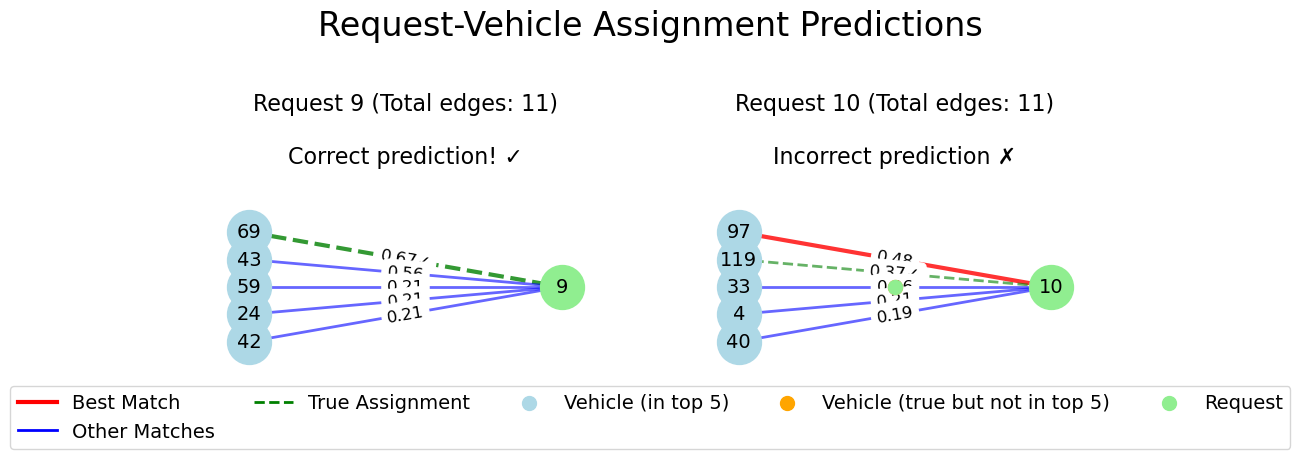

In [20]:
from gnn_project.analysis.plots import visualize_graph
from gnn_project.training.train_utils import get_edge_predictions

graph_idx = 12  # Index of the graph to visualize
predictions = get_edge_predictions(data[graph_idx], model, device='cpu')
visualize_graph(data, graph_idx=graph_idx, predictions=predictions, device=config.device, only_new_requests=True);

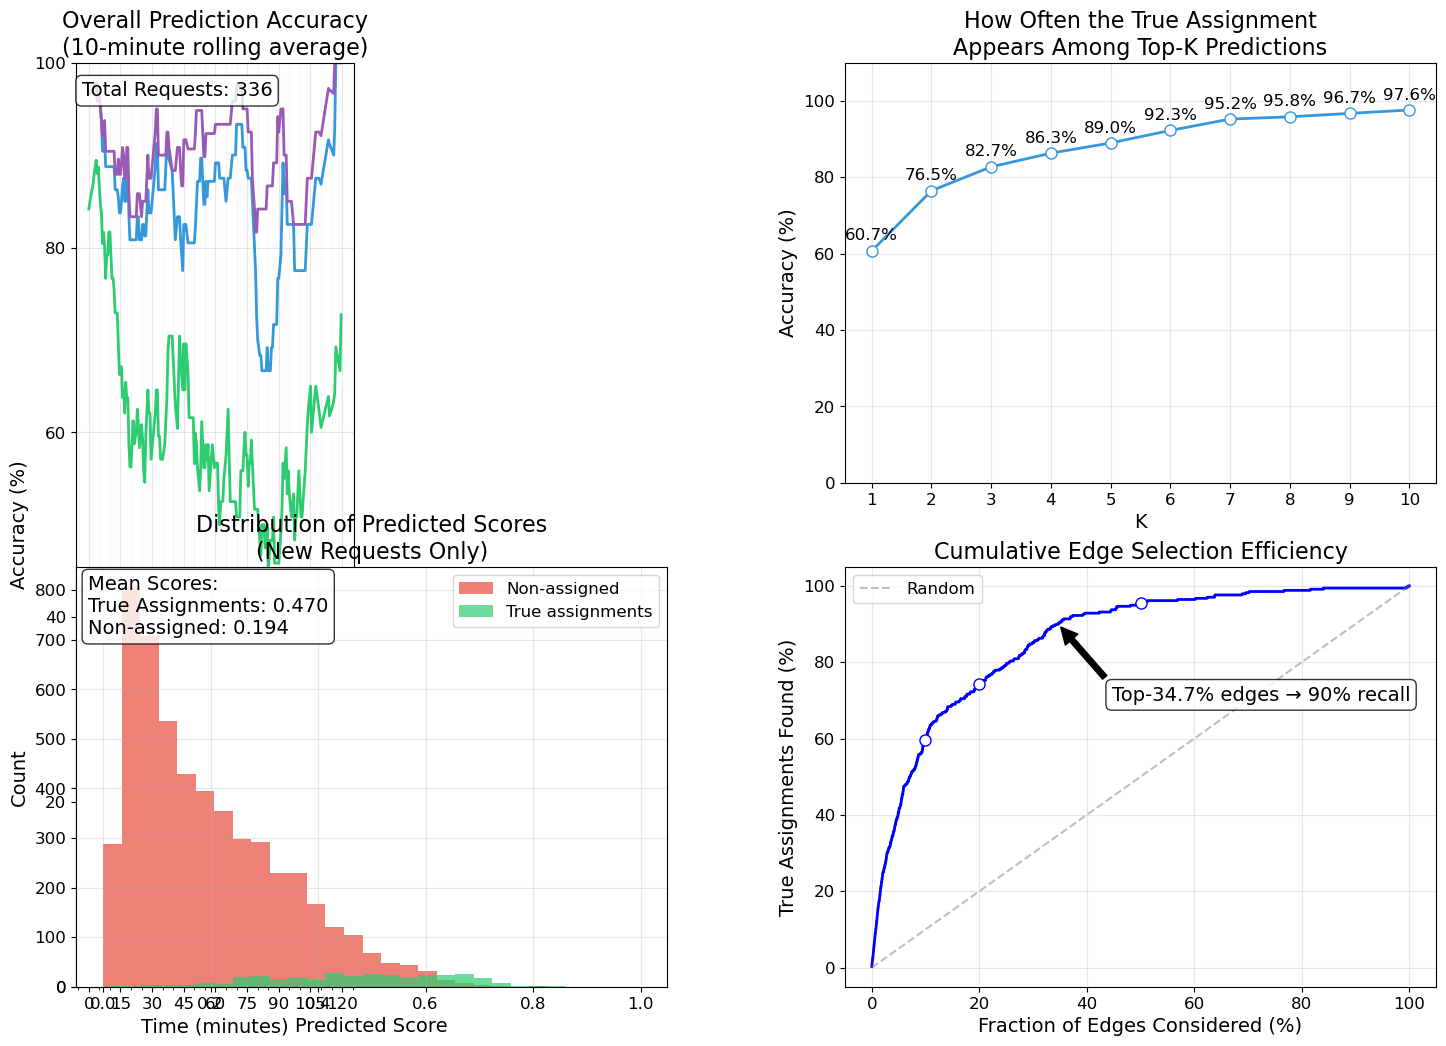

In [8]:
# Analyze model performance over a range of graphs
from gnn_project.analysis.plots import analyze_model_performance
import matplotlib.pyplot as plt
start_idx = 480  # Starting graph index
num_graphs = 240  # Number of graphs to analyze

# TODO split to separate plots
# TODO get all graph predictions at once
predictions = [get_edge_predictions(data[i], model, device='cpu') for i in range(start_idx, start_idx + num_graphs)]
fig = analyze_model_performance(data, start_idx, num_graphs, predictions, config.device)
if fig:
    plt.show()